In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import argparse
import wandb

# Make sure src/ is on the path - adjust if your notebook is outside src/
sys.path.insert(0, os.path.abspath("../src"))  # run notebook from inside src/

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

In [2]:
wandb.login()

WANDB_PROJECT = "da6401_assignment_1"   # ← change to your project name
WANDB_ENTITY  = None

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.
wandb: Currently logged in as: shlokshetty2304 (shlokshetty2304-iitm-ac-in) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
def make_config(dataset="mnist", epochs=10, batch_size=64, lr=0.001,
                optimizer="adam", num_layers=3, hidden_size=None,
                activation="relu", weight_init="xavier",
                loss="cross_entropy", weight_decay=0.0):
    if hidden_size is None:
        hidden_size = [128] * num_layers
    return argparse.Namespace(
        dataset=dataset, epochs=epochs, batch_size=batch_size,
        learning_rate=lr, optimizer=optimizer, num_layers=num_layers,
        hidden_size=hidden_size, activation=activation,
        weight_init=weight_init, loss=loss, weight_decay=weight_decay,
    )

In [4]:
def run_experiment(cfg, X_train, y_train, X_val, y_val, X_test, y_test,
                   run_name, tags=None, log_gradients=False,
                   log_activations=False, extra_config=None):
    """Train model, log everything to W&B, return (model, metrics)."""

    config_dict = vars(cfg).copy()
    if extra_config:
        
        config_dict.update(extra_config)

    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=run_name,
        tags=tags or [],
        config=config_dict,
        reinit=True,
    )

    model = NeuralNetwork(cfg)
    model.train(X_train, y_train, X_val=X_val, y_val=y_val,
                wandb_run=run, log_gradients=log_gradients)

    # Test metrics
    logits   = model.forward(X_test)
    loss_val = model.loss_fn.loss(logits, y_test)
    y_pred   = np.argmax(logits, axis=1)
    acc  = float(np.mean(y_pred == y_test))
    f1   = float(f1_score(y_test, y_pred, average="macro", zero_division=0))
    prec = float(precision_score(y_test, y_pred, average="macro", zero_division=0))
    rec  = float(recall_score(y_test, y_pred, average="macro", zero_division=0))

    run.log({"test_loss": loss_val, "test_acc": acc,
             "test_f1": f1, "test_precision": prec, "test_recall": rec})

    # Log activation histograms (Q2.5)
    if log_activations:
        sample = X_test[:500]
        a = sample.copy()
        for li, layer in enumerate(model.layers[:-1]):
            a = layer.forward(a)
            dead = float(np.mean(a == 0))
            run.log({f"dead_neuron_frac_layer{li}": dead})
            fig, ax = plt.subplots(figsize=(5, 3))
            ax.hist(a.flatten(), bins=50, color="steelblue", alpha=0.8)
            ax.set_title(f"Layer {li} activations – {cfg.activation} lr={cfg.learning_rate}")
            ax.set_xlabel("Activation value")
            run.log({f"activation_hist_layer{li}": wandb.Image(fig)})
            plt.close(fig)

    run.finish()
    print(f"  {run_name}  acc={acc:.4f}  f1={f1:.4f}")
    return model, {"loss": loss_val, "acc": acc, "f1": f1}


In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data(
    dataset="mnist", val_split=0.1, seed=42
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Loaded mnist: train=54000, val=6000, test=10000
Train: (54000, 784)  Val: (6000, 784)  Test: (10000, 784)


In [6]:
from keras.datasets import mnist as keras_mnist
(X_raw, y_raw), _ = keras_mnist.load_data()

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                 name="q2_1_class_samples", tags=["q2.1"], reinit=True)

labels = [str(i) for i in range(10)]
columns = ["class_id", "class_name"] + [f"sample_{i+1}" for i in range(5)]
table = wandb.Table(columns=columns)

for cls in range(10):
    idxs = np.where(y_raw == cls)[0][:5]
    images = [wandb.Image(X_raw[i]) for i in idxs]
    table.add_data(cls, labels[cls], *images)

run.log({"class_samples": table})
run.finish()
print("Q2.1 done - check W&B for class_samples table")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Q2.1 done - check W&B for class_samples table


In [7]:
optimizers_to_test = {
    "sgd":      0.01,
    "momentum": 0.01,
    "nag":      0.01,
    "rmsprop":  0.001,
}

for opt, lr in optimizers_to_test.items():
    print(f"Running optimizer: {opt}")
    cfg = make_config(optimizer=opt, lr=lr, epochs=10,
                      hidden_size=[128, 128, 128])
    run_experiment(cfg, X_train, y_train, X_val, y_val, X_test, y_test,
                   run_name=f"q2_3_{opt}",
                   tags=["q2.3", "optimizer_comparison"],
                   extra_config={"experiment": "optimizer_comparison"})

print("Q2.3 done - compare train_loss curves in W&B grouped by run")

Running optimizer: sgd


Epoch 1/10  train_loss=1.0797  train_acc=0.7182  val_loss=0.4463  val_acc=0.8765
Epoch 2/10  train_loss=0.3760  train_acc=0.8919  val_loss=0.3461  val_acc=0.9002
Epoch 3/10  train_loss=0.3084  train_acc=0.9114  val_loss=0.3029  val_acc=0.9105
Epoch 4/10  train_loss=0.2692  train_acc=0.9227  val_loss=0.2657  val_acc=0.9223
Epoch 5/10  train_loss=0.2381  train_acc=0.9310  val_loss=0.2444  val_acc=0.9288
Epoch 6/10  train_loss=0.2140  train_acc=0.9391  val_loss=0.2190  val_acc=0.9362
Epoch 7/10  train_loss=0.1939  train_acc=0.9445  val_loss=0.2045  val_acc=0.9415
Epoch 8/10  train_loss=0.1765  train_acc=0.9491  val_loss=0.1850  val_acc=0.9468
Epoch 9/10  train_loss=0.1625  train_acc=0.9526  val_loss=0.1732  val_acc=0.9515
Epoch 10/10  train_loss=0.1504  train_acc=0.9571  val_loss=0.1657  val_acc=0.9535


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▆▇▇▇▇████
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▃▄▅▆▆▇▇██
val_loss,█▅▄▃▃▂▂▁▁▁
epoch,10


  q2_3_sgd  acc=0.9556  f1=0.9552
Running optimizer: momentum


Epoch 1/10  train_loss=0.3843  train_acc=0.8869  val_loss=0.2220  val_acc=0.9315
Epoch 2/10  train_loss=0.1530  train_acc=0.9543  val_loss=0.1365  val_acc=0.9597
Epoch 3/10  train_loss=0.1080  train_acc=0.9664  val_loss=0.1117  val_acc=0.9645
Epoch 4/10  train_loss=0.0804  train_acc=0.9751  val_loss=0.1079  val_acc=0.9682
Epoch 5/10  train_loss=0.0650  train_acc=0.9800  val_loss=0.0977  val_acc=0.9725
Epoch 6/10  train_loss=0.0530  train_acc=0.9838  val_loss=0.0975  val_acc=0.9710
Epoch 7/10  train_loss=0.0436  train_acc=0.9867  val_loss=0.1040  val_acc=0.9710
Epoch 8/10  train_loss=0.0349  train_acc=0.9894  val_loss=0.0882  val_acc=0.9745
Epoch 9/10  train_loss=0.0296  train_acc=0.9910  val_loss=0.0970  val_acc=0.9733
Epoch 10/10  train_loss=0.0262  train_acc=0.9916  val_loss=0.0984  val_acc=0.9720


...

epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▆▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▅▇▇▇▇█▇██
val_loss,█▄▂▂▂▁▁▁▁▂
epoch,10


  q2_3_nag  acc=0.9717  f1=0.9715
Running optimizer: rmsprop


Epoch 1/10  train_loss=0.2642  train_acc=0.9209  val_loss=0.1410  val_acc=0.9610
Epoch 2/10  train_loss=0.1114  train_acc=0.9668  val_loss=0.1332  val_acc=0.9610
Epoch 3/10  train_loss=0.0787  train_acc=0.9758  val_loss=0.1027  val_acc=0.9708
Epoch 4/10  train_loss=0.0617  train_acc=0.9813  val_loss=0.0961  val_acc=0.9748
Epoch 5/10  train_loss=0.0478  train_acc=0.9855  val_loss=0.1117  val_acc=0.9732
Epoch 6/10  train_loss=0.0422  train_acc=0.9875  val_loss=0.1114  val_acc=0.9725
Epoch 7/10  train_loss=0.0348  train_acc=0.9896  val_loss=0.1119  val_acc=0.9747
Epoch 8/10  train_loss=0.0288  train_acc=0.9911  val_loss=0.1422  val_acc=0.9735
Epoch 9/10  train_loss=0.0276  train_acc=0.9919  val_loss=0.1453  val_acc=0.9748
Epoch 10/10  train_loss=0.0230  train_acc=0.9933  val_loss=0.2035  val_acc=0.9657


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▁▆█▇▇█▇█▃
val_loss,▄▃▁▁▂▂▂▄▄█
epoch,10


  q2_3_rmsprop  acc=0.9622  f1=0.9622
✅ Q2.3 done - compare train_loss curves in W&B grouped by run


In [8]:
grad_configs = [
    ("sigmoid", 3, [128, 128, 128]),
    ("relu",    3, [128, 128, 128]),
    ("sigmoid", 5, [64, 64, 64, 64, 64]),
    ("relu",    5, [64, 64, 64, 64, 64]),
]

for act, nl, hs in grad_configs:
    print(f"Running: {act} {nl}-layer")
    cfg = make_config(optimizer="rmsprop", lr=0.001, epochs=10,
                      activation=act, num_layers=nl, hidden_size=hs)
    run_experiment(cfg, X_train, y_train, X_val, y_val, X_test, y_test,
                   run_name=f"q2_4_{act}_{nl}layer",
                   tags=["q2.4", "vanishing_gradient"],
                   log_gradients=True,
                   extra_config={"experiment": "vanishing_gradient"})

print("Q2.4 done - plot grad_norm_layer0 in W&B, group by activation")


Running: sigmoid 3-layer


Epoch 1/10  train_loss=0.6403  train_acc=0.8151  val_loss=0.2925  val_acc=0.9103
Epoch 2/10  train_loss=0.2348  train_acc=0.9312  val_loss=0.2135  val_acc=0.9367
Epoch 3/10  train_loss=0.1695  train_acc=0.9497  val_loss=0.1644  val_acc=0.9505
Epoch 4/10  train_loss=0.1335  train_acc=0.9606  val_loss=0.1343  val_acc=0.9590
Epoch 5/10  train_loss=0.1103  train_acc=0.9667  val_loss=0.1309  val_acc=0.9617
Epoch 6/10  train_loss=0.0925  train_acc=0.9726  val_loss=0.1208  val_acc=0.9660
Epoch 7/10  train_loss=0.0799  train_acc=0.9758  val_loss=0.1107  val_acc=0.9678
Epoch 8/10  train_loss=0.0705  train_acc=0.9786  val_loss=0.1135  val_acc=0.9667
Epoch 9/10  train_loss=0.0620  train_acc=0.9814  val_loss=0.0991  val_acc=0.9722
Epoch 10/10  train_loss=0.0550  train_acc=0.9836  val_loss=0.1094  val_acc=0.9708


epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,▂▃▂▅█▄▁▃▁▆
grad_neuron_l0_n1,▃▂▃▄▆█▁▅▃▄
grad_neuron_l0_n2,▃▂▁▁▂▅▁▆█▂
grad_neuron_l0_n3,▂▄▁▄█▄▂▃▂▇
grad_neuron_l0_n4,▄▂▂▁▁█▆█▂▃
grad_neuron_l1_n0,▂▄▅▅▄▅██▁▃
grad_neuron_l1_n1,▂▂▁▁▂▁▇█▄▂
grad_neuron_l1_n2,▄▁▂▅▂▇▅█▂▄
grad_neuron_l1_n3,▅▂▁▅▇▆▁█▁▄
+18,...


  q2_4_sigmoid_3layer  acc=0.9759  f1=0.9757
Running: relu 3-layer


Epoch 1/10  train_loss=0.2640  train_acc=0.9201  val_loss=0.1535  val_acc=0.9540
Epoch 2/10  train_loss=0.1131  train_acc=0.9660  val_loss=0.1373  val_acc=0.9607
Epoch 3/10  train_loss=0.0792  train_acc=0.9746  val_loss=0.1044  val_acc=0.9710
Epoch 4/10  train_loss=0.0620  train_acc=0.9819  val_loss=0.1415  val_acc=0.9603
Epoch 5/10  train_loss=0.0500  train_acc=0.9849  val_loss=0.1091  val_acc=0.9722
Epoch 6/10  train_loss=0.0399  train_acc=0.9881  val_loss=0.1192  val_acc=0.9760
Epoch 7/10  train_loss=0.0342  train_acc=0.9894  val_loss=0.1171  val_acc=0.9768
Epoch 8/10  train_loss=0.0296  train_acc=0.9911  val_loss=0.1322  val_acc=0.9743
Epoch 9/10  train_loss=0.0250  train_acc=0.9922  val_loss=0.1541  val_acc=0.9727
Epoch 10/10  train_loss=0.0221  train_acc=0.9931  val_loss=0.1553  val_acc=0.9710


...

epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,▂▅▄▁▂█▃▁▂▇
grad_neuron_l0_n1,▂▃▂▂▁▂▅▁▁█
grad_neuron_l0_n2,▂▆▃▁▂▄▅▂▂█
grad_neuron_l0_n3,▃▃▂▄▂▆▇▁▂█
grad_neuron_l0_n4,▃▃▂▃▁▃▂▃▂█
grad_neuron_l1_n0,▁▂▄▃▁▂▄▇▁█
grad_neuron_l1_n1,▃▄▆▄▂▃▃▃▁█
grad_neuron_l1_n2,▁▃█▃▁▂▅█▁▄
grad_neuron_l1_n3,▁▂▆▂▁▃██▁▄
+30,...


  q2_4_sigmoid_5layer  acc=0.9398  f1=0.9391
Running: relu 5-layer


Epoch 1/10  train_loss=0.3338  train_acc=0.8986  val_loss=0.2029  val_acc=0.9432
Epoch 2/10  train_loss=0.1468  train_acc=0.9564  val_loss=0.1460  val_acc=0.9597
Epoch 3/10  train_loss=0.1097  train_acc=0.9673  val_loss=0.1231  val_acc=0.9677
Epoch 4/10  train_loss=0.0918  train_acc=0.9729  val_loss=0.1503  val_acc=0.9580
Epoch 5/10  train_loss=0.0788  train_acc=0.9770  val_loss=0.1436  val_acc=0.9603
Epoch 6/10  train_loss=0.0680  train_acc=0.9797  val_loss=0.1223  val_acc=0.9688
Epoch 7/10  train_loss=0.0610  train_acc=0.9818  val_loss=0.1387  val_acc=0.9703
Epoch 8/10  train_loss=0.0541  train_acc=0.9841  val_loss=0.1307  val_acc=0.9708
Epoch 9/10  train_loss=0.0503  train_acc=0.9849  val_loss=0.1436  val_acc=0.9722
Epoch 10/10  train_loss=0.0441  train_acc=0.9866  val_loss=0.1355  val_acc=0.9710


epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,█▃▁▂▄▁▅▁▁▄
grad_neuron_l0_n1,█▂▂▁▁▂▂▁▂▁
grad_neuron_l0_n2,▂▂▁▁▂▁▁▃▄█
grad_neuron_l0_n3,▆▄▃▃▁▁█▁▁▁
grad_neuron_l0_n4,▂▄▄█▂▁▇▁▁▄
grad_neuron_l1_n0,▅▂█▃▁▁▁▂▁▁
grad_neuron_l1_n1,▆▂▆█▁▁█▁▂▃
grad_neuron_l1_n2,▁▁▁█▂▁█▁▂▂
grad_neuron_l1_n3,█▄▂█▃▄▄▁▃▂
+30,...


  q2_4_relu_5layer  acc=0.9723  f1=0.9721
Q2.4 done - plot grad_norm_layer0 in W&B, group by activation


In [9]:
dead_neuron_configs = [
    ("relu", 0.1,   "relu_high_lr"),
    ("relu", 0.001, "relu_low_lr"),
    ("tanh", 0.1,   "tanh_high_lr"),
    ("tanh", 0.001, "tanh_low_lr"),
]

for act, lr, name in dead_neuron_configs:
    print(f"Running: {name}")
    cfg = make_config(optimizer="sgd", lr=lr, epochs=10,
                      activation=act, hidden_size=[128, 128, 128])
    run_experiment(cfg, X_train, y_train, X_val, y_val, X_test, y_test,
                   run_name=f"q2_5_{name}",
                   tags=["q2.5", "dead_neurons"],
                   log_gradients=True,
                   log_activations=True,
                   extra_config={"experiment": "dead_neurons"})

print("Q2.5 done - check dead_neuron_frac_* and activation histograms in W&B")

Running: relu_high_lr


Epoch 1/10  train_loss=0.3638  train_acc=0.8918  val_loss=0.1762  val_acc=0.9480
Epoch 2/10  train_loss=0.1471  train_acc=0.9563  val_loss=0.1356  val_acc=0.9588
Epoch 3/10  train_loss=0.1033  train_acc=0.9682  val_loss=0.1117  val_acc=0.9680
Epoch 4/10  train_loss=0.0770  train_acc=0.9761  val_loss=0.1123  val_acc=0.9653
Epoch 5/10  train_loss=0.0620  train_acc=0.9807  val_loss=0.1075  val_acc=0.9688
Epoch 6/10  train_loss=0.0501  train_acc=0.9848  val_loss=0.0889  val_acc=0.9732
Epoch 7/10  train_loss=0.0425  train_acc=0.9864  val_loss=0.1093  val_acc=0.9675
Epoch 8/10  train_loss=0.0331  train_acc=0.9899  val_loss=0.0942  val_acc=0.9750
Epoch 9/10  train_loss=0.0283  train_acc=0.9912  val_loss=0.1245  val_acc=0.9668
Epoch 10/10  train_loss=0.0243  train_acc=0.9925  val_loss=0.0926  val_acc=0.9745


dead_neuron_frac_layer0,▁
dead_neuron_frac_layer1,▁
dead_neuron_frac_layer2,▁
epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,▁▂▂█▄▂▂▃▁▂
grad_neuron_l0_n1,▃▁▃▃▂▅█▄▃▁
grad_neuron_l0_n2,▂▂▂▆▂▁█▁▁▁
grad_neuron_l0_n3,▂▂▃▃▂▁▃▂█▁
grad_neuron_l0_n4,▅█▄▂▁▂▁▆▁█
grad_neuron_l1_n0,▁▁▁▁▁▁▂▁█▁
+21,...


  q2_5_relu_high_lr  acc=0.9777  f1=0.9774
Running: relu_low_lr


Epoch 1/10  train_loss=2.1911  train_acc=0.2504  val_loss=2.0738  val_acc=0.4125
Epoch 2/10  train_loss=1.9093  train_acc=0.5259  val_loss=1.7116  val_acc=0.6268
Epoch 3/10  train_loss=1.4770  train_acc=0.6924  val_loss=1.2413  val_acc=0.7422
Epoch 4/10  train_loss=1.0445  train_acc=0.7849  val_loss=0.8890  val_acc=0.8115
Epoch 5/10  train_loss=0.7777  train_acc=0.8273  val_loss=0.6991  val_acc=0.8412
Epoch 6/10  train_loss=0.6342  train_acc=0.8477  val_loss=0.5931  val_acc=0.8557
Epoch 7/10  train_loss=0.5504  train_acc=0.8593  val_loss=0.5283  val_acc=0.8628
Epoch 8/10  train_loss=0.4964  train_acc=0.8675  val_loss=0.4854  val_acc=0.8722
Epoch 9/10  train_loss=0.4591  train_acc=0.8738  val_loss=0.4555  val_acc=0.8773
Epoch 10/10  train_loss=0.4315  train_acc=0.8789  val_loss=0.4312  val_acc=0.8805


...

dead_neuron_frac_layer0,▁
dead_neuron_frac_layer1,▁
dead_neuron_frac_layer2,▁
epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,█▂▄▂▁█▁▆▂▄
grad_neuron_l0_n1,▇▃▃▃▁▂▁▄▆█
grad_neuron_l0_n2,█▃▄▆▂▁▁▅▂▆
grad_neuron_l0_n3,█▂▁▃▃▂▁▇█▄
grad_neuron_l0_n4,█▂▂▃▂▁▂▆█▁
grad_neuron_l1_n0,▆▂▁▃▅▁▂▂█▄
+21,...


  q2_5_tanh_high_lr  acc=0.9748  f1=0.9745
Running: tanh_low_lr


Epoch 1/10  train_loss=1.8098  train_acc=0.4949  val_loss=1.3985  val_acc=0.7008
Epoch 2/10  train_loss=1.1547  train_acc=0.7536  val_loss=0.9697  val_acc=0.7873
Epoch 3/10  train_loss=0.8567  train_acc=0.8084  val_loss=0.7674  val_acc=0.8235
Epoch 4/10  train_loss=0.7031  train_acc=0.8361  val_loss=0.6525  val_acc=0.8423
Epoch 5/10  train_loss=0.6107  train_acc=0.8531  val_loss=0.5800  val_acc=0.8560
Epoch 6/10  train_loss=0.5492  train_acc=0.8647  val_loss=0.5299  val_acc=0.8663
Epoch 7/10  train_loss=0.5055  train_acc=0.8733  val_loss=0.4933  val_acc=0.8742
Epoch 8/10  train_loss=0.4728  train_acc=0.8793  val_loss=0.4651  val_acc=0.8795
Epoch 9/10  train_loss=0.4474  train_acc=0.8840  val_loss=0.4436  val_acc=0.8828
Epoch 10/10  train_loss=0.4271  train_acc=0.8877  val_loss=0.4258  val_acc=0.8850


dead_neuron_frac_layer0,▁
dead_neuron_frac_layer1,▁
dead_neuron_frac_layer2,▁
epoch,▁▂▃▃▄▅▆▆▇█
grad_neuron_l0_n0,▆▃▃▁▁▇▄▆█▁
grad_neuron_l0_n1,▇▅▃▇▂▃▁▆▇█
grad_neuron_l0_n2,▄▃▁▃▂▂▁▃█▂
grad_neuron_l0_n3,▅▃▆▃▁▃▃▃▆█
grad_neuron_l0_n4,█▃▆█▃▃▇▇▇▁
grad_neuron_l1_n0,▄█▂▃▃▂▂▂▃▁
+21,...


  q2_5_tanh_low_lr  acc=0.8963  f1=0.8947
Q2.5 done - check dead_neuron_frac_* and activation histograms in W&B


In [10]:
for loss_fn in ["cross_entropy", "mse"]:
    print(f"Running loss: {loss_fn}")
    cfg = make_config(optimizer="adam", lr=0.001, epochs=10,
                      loss=loss_fn, hidden_size=[128, 128, 128])
    run_experiment(cfg, X_train, y_train, X_val, y_val, X_test, y_test,
                   run_name=f"q2_6_{loss_fn}",
                   tags=["q2.6", "loss_comparison"],
                   extra_config={"experiment": "loss_comparison"})

print("Q2.6 done - compare train_loss curves in W&B")

Running loss: cross_entropy


Epoch 1/10  train_loss=0.2738  train_acc=0.9184  val_loss=0.1516  val_acc=0.9558
Epoch 2/10  train_loss=0.1097  train_acc=0.9667  val_loss=0.1120  val_acc=0.9683
Epoch 3/10  train_loss=0.0748  train_acc=0.9770  val_loss=0.1058  val_acc=0.9698
Epoch 4/10  train_loss=0.0559  train_acc=0.9829  val_loss=0.0981  val_acc=0.9732
Epoch 5/10  train_loss=0.0452  train_acc=0.9849  val_loss=0.1037  val_acc=0.9735
Epoch 6/10  train_loss=0.0353  train_acc=0.9890  val_loss=0.1114  val_acc=0.9722
Epoch 7/10  train_loss=0.0333  train_acc=0.9891  val_loss=0.1158  val_acc=0.9727
Epoch 8/10  train_loss=0.0280  train_acc=0.9910  val_loss=0.1073  val_acc=0.9772
Epoch 9/10  train_loss=0.0235  train_acc=0.9927  val_loss=0.0990  val_acc=0.9783
Epoch 10/10  train_loss=0.0192  train_acc=0.9939  val_loss=0.1110  val_acc=0.9745


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▅▆▇▇█████
train_loss,█▃▃▂▂▁▁▁▁▁
val_acc,▁▅▅▆▆▆▆██▇
val_loss,█▃▂▁▂▃▃▂▁▃
epoch,10


  q2_6_cross_entropy  acc=0.9744  f1=0.9742
Running loss: mse


Epoch 1/10  train_loss=0.1302  train_acc=0.9133  val_loss=0.0832  val_acc=0.9457
Epoch 2/10  train_loss=0.0589  train_acc=0.9619  val_loss=0.0584  val_acc=0.9617
Epoch 3/10  train_loss=0.0444  train_acc=0.9716  val_loss=0.0504  val_acc=0.9680
Epoch 4/10  train_loss=0.0352  train_acc=0.9779  val_loss=0.0441  val_acc=0.9735
Epoch 5/10  train_loss=0.0303  train_acc=0.9809  val_loss=0.0483  val_acc=0.9698
Epoch 6/10  train_loss=0.0266  train_acc=0.9830  val_loss=0.0453  val_acc=0.9727
Epoch 7/10  train_loss=0.0222  train_acc=0.9863  val_loss=0.0443  val_acc=0.9712
Epoch 8/10  train_loss=0.0222  train_acc=0.9862  val_loss=0.0503  val_acc=0.9682
Epoch 9/10  train_loss=0.0191  train_acc=0.9881  val_loss=0.0419  val_acc=0.9748
Epoch 10/10  train_loss=0.0195  train_acc=0.9878  val_loss=0.0453  val_acc=0.9715


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▆▆▇▇█████
train_loss,█▄▃▂▂▁▁▁▁▁
val_acc,▁▅▆█▇▇▇▆█▇
val_loss,█▄▂▁▂▂▁▂▁▂
epoch,10


  q2_6_mse  acc=0.9758  f1=0.9756
Q2.6 done - compare train_loss curves in W&B


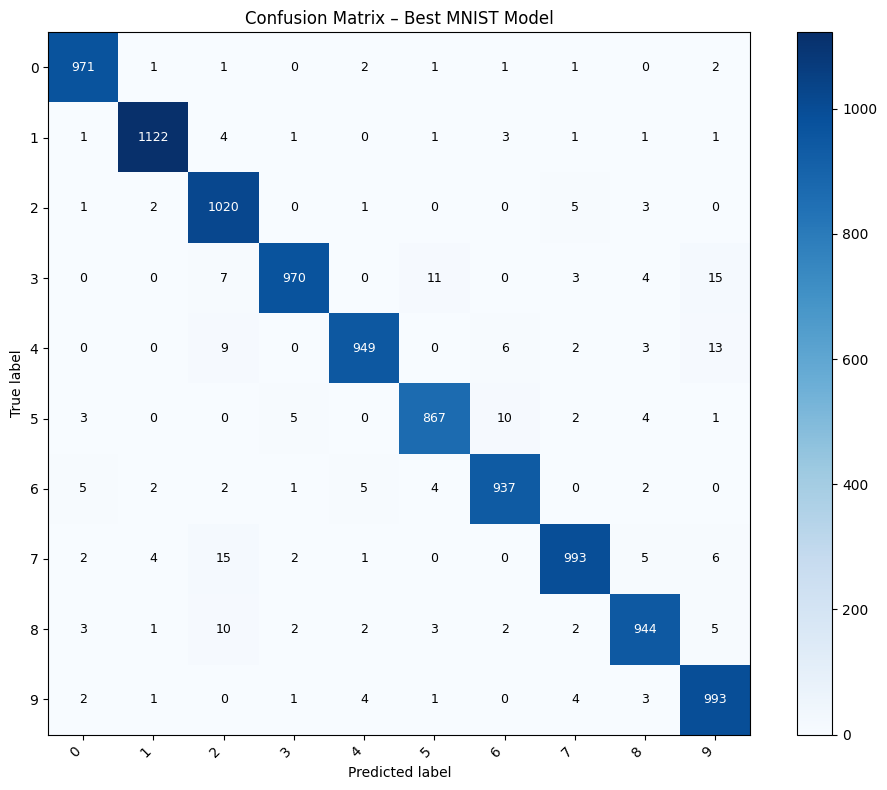

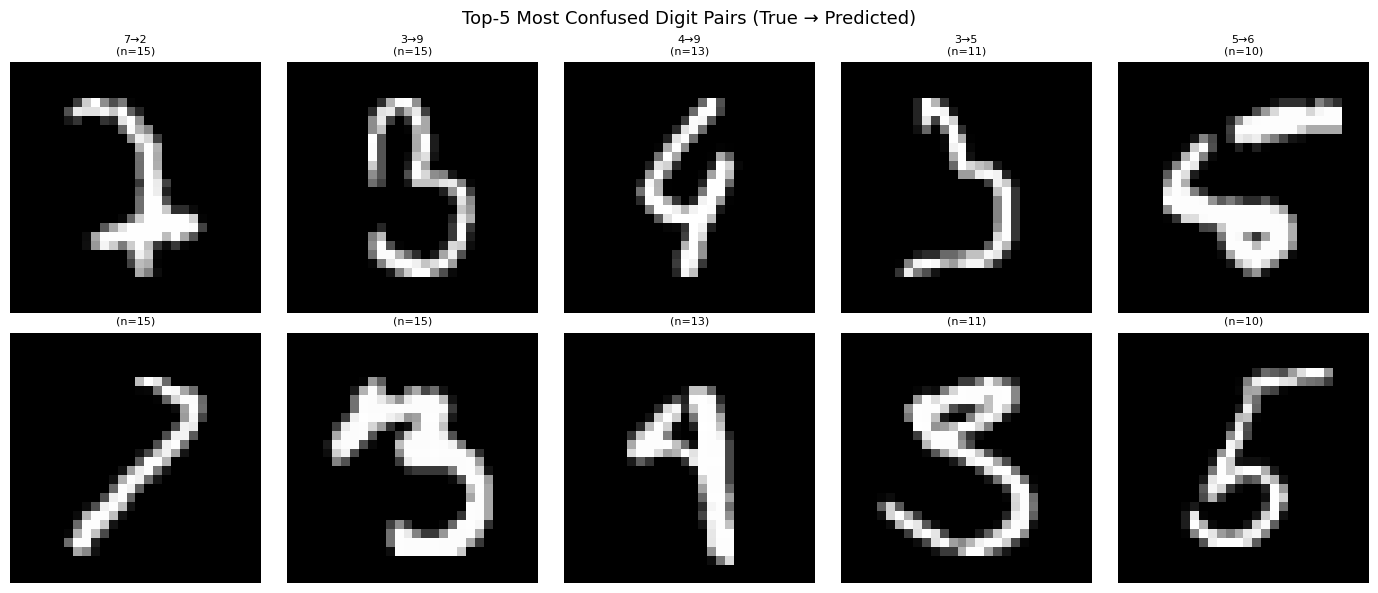

Q2.8 done - check confusion_matrix_plot and failure_visualization in W&B


In [14]:
from sklearn.metrics import confusion_matrix

# Load best model
cfg_best = make_config(optimizer="adam", lr=0.001, epochs=15,
                       hidden_size=[128, 128, 128])
model_best = NeuralNetwork(cfg_best)
weights = np.load("../src/best_model.npy", allow_pickle=True).item()
model_best.set_weights(weights)

logits_test = model_best.forward(X_test)
y_pred_best = np.argmax(logits_test, axis=1)
cm = confusion_matrix(y_test, y_pred_best)
digit_labels = [str(i) for i in range(10)]

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                 name="q2_8_confusion_matrix", tags=["q2.8"], reinit=True)

# ── Standard confusion matrix plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set(xticks=np.arange(10), yticks=np.arange(10),
       xticklabels=digit_labels, yticklabels=digit_labels,
       ylabel="True label", xlabel="Predicted label",
       title="Confusion Matrix – Best MNIST Model")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
thresh = cm.max() / 2.0
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=9)
plt.tight_layout()
run.log({"confusion_matrix_plot": wandb.Image(fig)})
plt.show()
plt.close(fig)

# ── Native W&B confusion matrix ───────────────────────────────────────────────
run.log({"confusion_matrix_native": wandb.plot.confusion_matrix(
    y_true=y_test.tolist(),
    preds=y_pred_best.tolist(),
    class_names=digit_labels
)})

# ── Creative: show top-5 most confused pairs with example images ───────────────
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
flat_idx = np.argsort(cm_no_diag.flatten())[::-1][:5]
pairs = [divmod(i, 10) for i in flat_idx]

X_img = (X_test * 255).reshape(-1, 28, 28).astype(np.uint8)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Top-5 Most Confused Digit Pairs (True → Predicted)", fontsize=13)
for col, (true_cls, pred_cls) in enumerate(pairs):
    mask = (y_test == true_cls) & (y_pred_best == pred_cls)
    idxs = np.where(mask)[0]
    for row in range(2):
        ax = axes[row, col]
        if len(idxs) > row:
            ax.imshow(X_img[idxs[row]], cmap="gray")
        ax.set_title(f"{true_cls}→{pred_cls}\n(n={cm[true_cls,pred_cls]})", fontsize=8)
        ax.axis("off")
plt.tight_layout()
run.log({"failure_visualization": wandb.Image(fig)})
plt.show()
plt.close(fig)

run.finish()
print("Q2.8 done - check confusion_matrix_plot and failure_visualization in W&B")


In [15]:
for init in ["zeros", "xavier"]:
    print(f"Running weight init: {init}")
    cfg = make_config(optimizer="adam", lr=0.001, epochs=10,
                      activation="relu", weight_init=init,
                      hidden_size=[128, 128, 128])

    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"q2_9_init_{init}",
                     tags=["q2.9", "weight_init"],
                     config={**vars(cfg), "experiment": "weight_init"},
                     reinit=True)

    model = NeuralNetwork(cfg)
    n, batch_size = X_train.shape[0], 64
    iteration = 0

    for epoch in range(cfg.epochs):
        idx = np.random.permutation(n)
        X_s, y_s = X_train[idx], y_train[idx]

        for start in range(0, n, batch_size):
            Xb = X_s[start:start + batch_size]
            yb = y_s[start:start + batch_size]

            logits = model.forward(Xb)
            model.backward(yb, logits)
            model.optimizer.step(model.layers)

            # Log neuron gradient norms for first 50 iterations
            if iteration < 50:
                log_dict = {"iteration": iteration}
                for ni in range(5):
                    log_dict[f"neuron_{ni}_grad_norm"] = float(
                        np.linalg.norm(model.layers[0].grad_W[:, ni])
                    )
                run.log(log_dict)
            iteration += 1

        # Log epoch loss
        logits_val = model.forward(X_val)
        val_loss = model.loss_fn.loss(logits_val, y_val)
        val_acc  = float(np.mean(np.argmax(logits_val, axis=1) == y_val))
        run.log({"epoch": epoch + 1, "val_loss": float(val_loss), "val_acc": val_acc})

    run.finish()
    print(f"   {init} done")

print("Q2.9 done - plot neuron_*_grad_norm vs iteration, group by init method")


Running weight init: zeros


epoch,▁▂▃▃▄▅▆▆▇█
iteration,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_1_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_2_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_3_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_4_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▂▄▆▃█▆▁▂
epoch,10
iteration,49


   zeros done
Running weight init: xavier


epoch,▁▂▃▃▄▅▆▆▇█
iteration,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,▃▂▂▁▄▂▆▂▄▂▂▃▂▄▂▇▂▅▃▅▄▄▃▂█▂▃▂▁▂▇▃▂▁▃▃▂▃▃▂
neuron_1_grad_norm,▁▂▃▁▄▁▃▆▄▂▄▂▂▃▂▅▆▅▃▄▃▂▃▃▅▂▃▂▂▆█▄▃▂▅▄▂▂▄▂
neuron_2_grad_norm,▂▂▃▂▃▁▂▂▂▂▃▂▂▄▃█▂▂▄▃▅▂▂▂▃▂▂▄▂▃▅▃▁▂▄▂▂▃▂▃
neuron_3_grad_norm,▃▁▂▂▂▂▂▁▁▄▆▃▃▃▅▇▃▅▅▅▅▄▅▅▅▄▅▆▇▇█▅▄▃▄▆▂▂▃▄
neuron_4_grad_norm,▂▂▂▃▃▂▆▆▇▃▄▅▆▃▂█▄▂▁▃▆▁▃▇▃█▇▃▂▃▅▄▂▂▃█▂▅▄█
val_acc,▁▅▇▅▆▇▆▇█▆
val_loss,█▃▁▃▃▂▃▄▂▅
epoch,10
iteration,49


   xavier done
Q2.9 done - plot neuron_*_grad_norm vs iteration, group by init method


In [16]:
print("Loading Fashion-MNIST...")
X_tr_f, y_tr_f, X_v_f, y_v_f, X_te_f, y_te_f = load_data(
    dataset="fashion_mnist", val_split=0.1, seed=42
)

fashion_configs = [
    # Config 1: Best MNIST setup (adam + relu + xavier)
    ("adam_relu_3x128",
     make_config(dataset="fashion_mnist", optimizer="adam", lr=0.001,
                 epochs=15, activation="relu", weight_init="xavier",
                 hidden_size=[128, 128, 128])),
    # Config 2: Deeper with tanh
    ("rmsprop_tanh_4x128",
     make_config(dataset="fashion_mnist", optimizer="rmsprop", lr=0.001,
                 epochs=15, activation="tanh", weight_init="xavier",
                 hidden_size=[128, 128, 128, 128])),
    # Config 3: Wider with momentum
    ("momentum_relu_256_128_64",
     make_config(dataset="fashion_mnist", optimizer="momentum", lr=0.01,
                 epochs=15, activation="relu", weight_init="xavier",
                 hidden_size=[256, 128, 64])),
]

for name, cfg in fashion_configs:
    print(f"Running: {name}")
    run_experiment(cfg, X_tr_f, y_tr_f, X_v_f, y_v_f, X_te_f, y_te_f,
                   run_name=f"q2_10_{name}",
                   tags=["q2.10", "fashion_transfer"],
                   extra_config={"experiment": "fashion_transfer"})

print("Q2.10 done - compare test_acc and test_f1 across 3 configs in W&B")

Loading Fashion-MNIST...
Loaded fashion_mnist: train=54000, val=6000, test=10000
Running: adam_relu_3x128


Epoch 1/15  train_loss=0.5141  train_acc=0.8152  val_loss=0.3704  val_acc=0.8692
Epoch 2/15  train_loss=0.3725  train_acc=0.8636  val_loss=0.3585  val_acc=0.8688
Epoch 3/15  train_loss=0.3360  train_acc=0.8758  val_loss=0.3727  val_acc=0.8653
Epoch 4/15  train_loss=0.3168  train_acc=0.8837  val_loss=0.3217  val_acc=0.8833
Epoch 5/15  train_loss=0.2972  train_acc=0.8890  val_loss=0.3113  val_acc=0.8862
Epoch 6/15  train_loss=0.2812  train_acc=0.8939  val_loss=0.3118  val_acc=0.8842
Epoch 7/15  train_loss=0.2670  train_acc=0.8998  val_loss=0.3005  val_acc=0.8902
Epoch 8/15  train_loss=0.2556  train_acc=0.9036  val_loss=0.3003  val_acc=0.8877
Epoch 9/15  train_loss=0.2438  train_acc=0.9083  val_loss=0.3131  val_acc=0.8840
Epoch 10/15  train_loss=0.2328  train_acc=0.9118  val_loss=0.2911  val_acc=0.8982
Epoch 11/15  train_loss=0.2235  train_acc=0.9152  val_loss=0.2955  val_acc=0.8957
Epoch 12/15  train_loss=0.2190  train_acc=0.9169  val_loss=0.2931  val_acc=0.8955
Epoch 13/15  train_loss=0

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇███
train_loss,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▂▂▁▅▅▅▆▆▅█▇▇▇▇▇
val_loss,█▇█▄▃▃▂▂▃▁▁▁▂▂▂
epoch,15


  q2_10_adam_relu_3x128  acc=0.8860  f1=0.8859
Running: rmsprop_tanh_4x128


Epoch 1/15  train_loss=0.5370  train_acc=0.8006  val_loss=0.4018  val_acc=0.8518
Epoch 2/15  train_loss=0.3988  train_acc=0.8530  val_loss=0.3481  val_acc=0.8635
Epoch 3/15  train_loss=0.3535  train_acc=0.8696  val_loss=0.3376  val_acc=0.8702
Epoch 4/15  train_loss=0.3254  train_acc=0.8797  val_loss=0.3404  val_acc=0.8702
Epoch 5/15  train_loss=0.3073  train_acc=0.8850  val_loss=0.3145  val_acc=0.8857
Epoch 6/15  train_loss=0.2908  train_acc=0.8915  val_loss=0.3184  val_acc=0.8803
Epoch 7/15  train_loss=0.2756  train_acc=0.8969  val_loss=0.2915  val_acc=0.8927
Epoch 8/15  train_loss=0.2635  train_acc=0.8999  val_loss=0.3203  val_acc=0.8800
Epoch 9/15  train_loss=0.2535  train_acc=0.9058  val_loss=0.3031  val_acc=0.8908
Epoch 10/15  train_loss=0.2427  train_acc=0.9078  val_loss=0.3077  val_acc=0.8893
Epoch 11/15  train_loss=0.2324  train_acc=0.9112  val_loss=0.2966  val_acc=0.8930
Epoch 12/15  train_loss=0.2251  train_acc=0.9147  val_loss=0.3045  val_acc=0.8927
Epoch 13/15  train_loss=0

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▄▅▆▆▆▇▇▇▇▇████
train_loss,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▃▄▄▆▆█▆▇▇███▇▇
val_loss,█▅▄▄▂▃▁▃▂▂▁▂▂▂▂
epoch,15


  q2_10_rmsprop_tanh_4x128  acc=0.8800  f1=0.8797
Running: momentum_relu_256_128_64


Epoch 1/15  train_loss=0.5662  train_acc=0.8002  val_loss=0.4314  val_acc=0.8443
Epoch 2/15  train_loss=0.3989  train_acc=0.8559  val_loss=0.3603  val_acc=0.8690
Epoch 3/15  train_loss=0.3605  train_acc=0.8687  val_loss=0.3584  val_acc=0.8707
Epoch 4/15  train_loss=0.3315  train_acc=0.8776  val_loss=0.3325  val_acc=0.8827
Epoch 5/15  train_loss=0.3102  train_acc=0.8855  val_loss=0.3249  val_acc=0.8782
Epoch 6/15  train_loss=0.2945  train_acc=0.8899  val_loss=0.3079  val_acc=0.8860
Epoch 7/15  train_loss=0.2793  train_acc=0.8956  val_loss=0.2981  val_acc=0.8908
Epoch 8/15  train_loss=0.2714  train_acc=0.8985  val_loss=0.3102  val_acc=0.8862
Epoch 9/15  train_loss=0.2607  train_acc=0.9028  val_loss=0.2949  val_acc=0.8903
Epoch 10/15  train_loss=0.2502  train_acc=0.9068  val_loss=0.2948  val_acc=0.8872
Epoch 11/15  train_loss=0.2394  train_acc=0.9109  val_loss=0.2980  val_acc=0.8935
Epoch 12/15  train_loss=0.2327  train_acc=0.9133  val_loss=0.2893  val_acc=0.8933
Epoch 13/15  train_loss=0

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▄▅▆▆▆▇▇▇▇▇████
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▄▅▆▆▇▇▇▇▇███▇█
val_loss,█▄▄▃▃▂▁▂▁▁▁▁▂▂▁
epoch,15


  q2_10_momentum_relu_256_128_64  acc=0.8821  f1=0.8820
Q2.10 done - compare test_acc and test_f1 across 3 configs in W&B
